# Assignment 2 — Statistical Decision Theory, Estimation & Black–Litterman

---

**Dataset.** Yahoo Finance daily bars, 2019-01-02 to 2024-12-31 (1,456 trading days), four parquet files in `Quant\HW2\data`:

| Symbol | Name | Role |
|--------|------|------|
| 0050.TW | 元大台灣 50 ETF | Market proxy |
| 2330.TW | 台積電 (TSMC) | Main target for §1–§2 |
| 2317.TW | 鴻海 (Foxconn) | BL relative-view counterpart |
| 2882.TW | 國泰金 (Cathay FHC) | BL absolute-view target |


---

## 1. Statistical Decision Theory

### 1.1 Problem Formulation

> *Spec:* "Describe a specific statistical decision problem using your assigned dataset."

Each morning, decide whether to hold a one-day long position in TSMC (2330). Let $Y_{t+1} = \mathbf{1}\{r_{t+1} > 0\}$ — the next-day up/down indicator — with $Y_{t+1} \sim \text{Ber}(p)$.

- **Action.** $a \in \{0, 1\}$ (flat / long).
- **Unknown.** $p \in [0, 1]$, the probability of an up day.
- **Loss.** 0–1 loss: $L(a, y) = \mathbf{1}\{a \neq y\}$. Expected loss is $a(1-p) + (1-a)p$, minimised by $a=1$ iff $p > 1/2$.
- **Decision rule.** $\delta$ maps the recent history $Y_{t-n+1:t}$ to today's action.


### 1.2 Three perspectives

#### 1.2.1 Bayesian

Take a Beta prior $p \sim \text{Beta}(\alpha_0, \beta_0)$. With $k$ up days observed in $n$ days, the posterior is conjugate:
$$ p \mid x \sim \text{Beta}(\alpha_0 + k,\ \beta_0 + n - k), \qquad \mathbb{E}[p\mid x] = \frac{\alpha_0+k}{\alpha_0+\beta_0+n}. $$

Bayes rule under 0–1 loss: $a=1$ iff the posterior mean is $>1/2$.

We use $\text{Beta}(2, 2)$ — mean $0.5$, equivalent to 4 prior pseudo-observations. The prior gently pulls borderline cases toward "no opinion".


#### 1.2.2 Frequentist

No prior. Use the MLE $\hat p_n = k/n$ and the plug-in rule
$$ \delta_{\text{plug}}(x) = \mathbf{1}\{\hat p_n > 1/2\}. $$

By the LLN, $\hat p_n \to p$, so the rule chooses the correct action with probability $\to 1$ when $p \neq 1/2$. This is the comparator we report below.


#### 1.2.3 Interventional

Causal DAG of one-day prediction (small retail trader):

```
        M (market state)
        / \
       v   v
     X_t  r_{t+1}
            ^
            |   (no edge from A)
            A
```

For a trader whose order size doesn't move prices, there is no edge $A \to r_{t+1}$, so $P(r_{t+1} \mid \text{do}(A=a)) = P(r_{t+1})$. The interventional rule reduces to the observational (Bayesian) one — we only benefit from conditioning on $X_t$, not from "intervening".

For an institutional trader where orders cause price impact, the edge $A \to r_{t+1}$ would exist and the analysis would differ.

---

The empirical illustration below compares the Bayesian and Frequentist rules; the interventional rule is identical to the Bayesian one under our assumption.


Loaded 1455 returns; up-day frequency overall = 0.4942

Empirical misclassification rate (lookback N=60):
  Bayesian (Beta(2,2) prior): 0.4846
  Frequentist (MLE plug-in):  0.4846
  Always-long baseline:       0.5090
  No-info Bayes risk:         0.5000


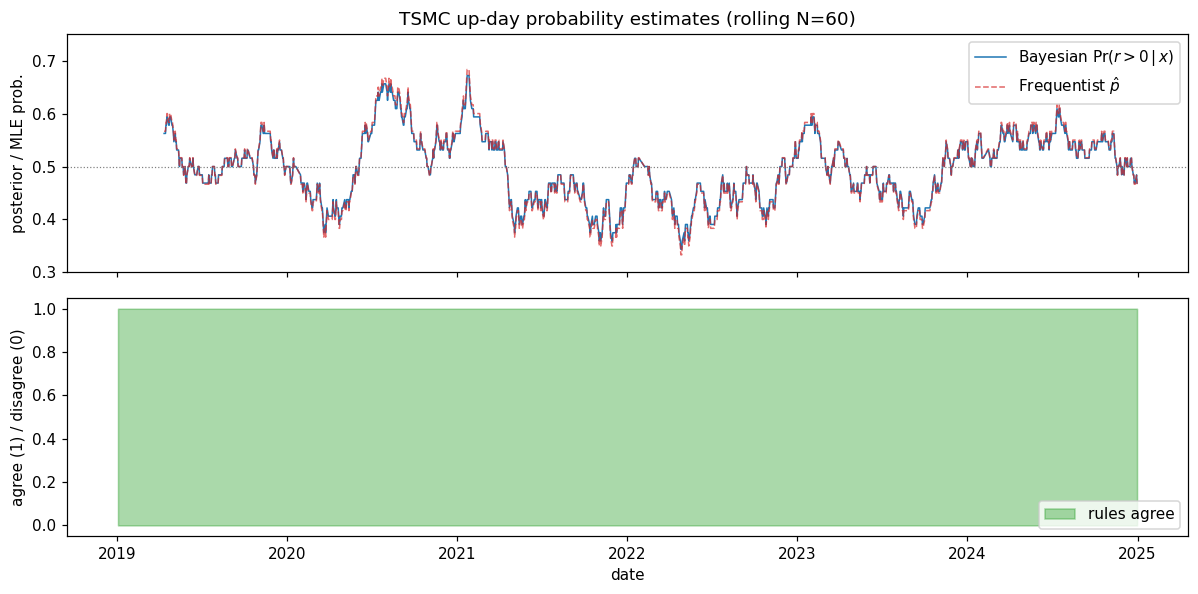


Rules agree on 100.0% of days (data-driven; prior matters mostly near 50/50).


In [1]:
# Section 1 empirical: long-vs-flat on TSMC daily
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

DATA = Path("data")
SYMBOLS = ["0050.TW", "2330.TW", "2317.TW", "2882.TW"]
START, END = "2019-01-02", "2024-12-31"


def load_returns():
    closes = {}
    for sym in SYMBOLS:
        df = pd.read_parquet(DATA / f"{sym}_1d.parquet").loc[START:END]
        closes[sym] = df["close"]
    prices = pd.concat(closes, axis=1).dropna()
    rets = np.log(prices / prices.shift(1)).dropna()
    return prices, rets


prices, rets = load_returns()
y = (rets["2330.TW"] > 0).astype(int)           # 1 = up day
print(f"Loaded {len(rets)} returns; up-day frequency overall = {y.mean():.4f}")

# Lookback window for both rules
N = 60

# Frequentist plug-in MLE
p_freq = y.rolling(N).mean().shift(1)            # use info up to t-1
a_freq = (p_freq > 0.5).astype(int)

# Bayesian posterior mean with Beta(2,2) prior
alpha0, beta0 = 2.0, 2.0
k = y.rolling(N).sum().shift(1)
p_bayes = (alpha0 + k) / (alpha0 + beta0 + N)
a_bayes = (p_bayes > 0.5).astype(int)

# Empirical risk = misclassification rate (drop warm-up window)
mask = p_freq.notna()
risk_freq  = (a_freq[mask]  != y[mask]).mean()
risk_bayes = (a_bayes[mask] != y[mask]).mean()
risk_naive = 1 - y[mask].mean()                 # always-long baseline
print(f"\nEmpirical misclassification rate (lookback N={N}):")
print(f"  Bayesian (Beta(2,2) prior): {risk_bayes:.4f}")
print(f"  Frequentist (MLE plug-in):  {risk_freq:.4f}")
print(f"  Always-long baseline:       {risk_naive:.4f}")
print(f"  No-info Bayes risk:         0.5000")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
axes[0].plot(p_bayes.index, p_bayes, label=r"Bayesian $\Pr(r>0\,|\,x)$", color="#1f77b4", lw=1)
axes[0].plot(p_freq.index, p_freq, label=r"Frequentist $\hat{p}$", color="#d62728", lw=1, ls="--", alpha=0.7)
axes[0].axhline(0.5, color="grey", ls=":", lw=0.8)
axes[0].set_ylabel("posterior / MLE prob.")
axes[0].set_ylim(0.3, 0.75)
axes[0].legend(loc="upper right")
axes[0].set_title(f"TSMC up-day probability estimates (rolling N={N})")

# Decision agreement panel
agree = (a_bayes == a_freq).astype(int)
axes[1].fill_between(agree.index, 0, agree, color="#2ca02c", alpha=0.4, label="rules agree")
axes[1].set_ylabel("agree (1) / disagree (0)")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_xlabel("date")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig("fig_s1_decision.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\nRules agree on {agree.mean():.1%} of days (data-driven; prior matters mostly near 50/50).")


---

## 2. Estimation Theory

### 2.1 Problem Formulation

> *Spec:* "Define an estimation problem relevant to your assigned dataset."

Estimate the annualised expected return $\mu$ of TSMC from $n$ daily log returns. Working model:
$$ r_i \stackrel{\text{iid}}{\sim} \mathcal{N}(\mu_d,\ \sigma_d^2), \qquad \mu = 252\,\mu_d, $$
with $\sigma_d$ replaced by its sample estimate when needed. Quadratic risk:
$$ \mathfrak{r}(\hat\mu) = \mathbb{E}[(\hat\mu - \mu)^2]. $$

$\mu$ is the key input to mean–variance allocation (and BL in §3), but very hard to estimate from finite samples — variance dominates the MSE for any reasonable $n$.


### 2.2 Three estimation frameworks

#### Bayesian
Conjugate Normal prior $\mu_d \sim \mathcal{N}(m_0, s_0^2)$ + Normal likelihood gives a Normal posterior. Point estimate = posterior mean:
$$ \hat\mu_d^{B} = \frac{m_0/s_0^2 + n\bar r/\sigma_d^2}{1/s_0^2 + n/\sigma_d^2}. $$
This is a shrinkage estimator — interpolates between the prior mean $m_0$ and the sample mean $\bar r$.

#### Frequentist (MLE)
Sample mean is the MLE:
$$ \hat\mu_d^{\text{MLE}} = \bar r = \tfrac{1}{n}\sum_i r_i. $$
Unbiased, variance $\sigma_d^2/n$.

#### M-estimation
Minimise an empirical loss $\sum_i \rho(r_i - m)$. Choices:
- $\rho(u) = u^2$ → sample mean.
- $\rho(u) = |u|$ → sample median (robust to outliers).
- **Huber** $\rho_c(u) = u^2/2$ for $|u| \le c$, else $c|u| - c^2/2$ — a compromise between mean and median that handles fat tails.

We use Huber with $c = 1.345\,\hat\sigma$ as the M-estimator comparator.


### 2.3 Risk Decomposition: bias² + variance

> *Spec:* "Prove the risk equation $\mathfrak{r}(\hat\theta) = \operatorname{bias}^2(\hat\theta) + \operatorname{var}(\hat\theta)$."

**Theorem.** For any estimator $\hat\theta$ of a fixed parameter $\theta$,
$$ \mathfrak{r}(\hat\theta) = \operatorname{bias}^2(\hat\theta) + \operatorname{var}(\hat\theta). $$

**Definitions.** Let $\mu := \mathbb{E}[\hat\theta]$.
- $\mathfrak{r}(\hat\theta) := \mathbb{E}[(\hat\theta - \theta)^2]$
- $\operatorname{bias}(\hat\theta) := \mathbb{E}[\hat\theta] - \theta = \mu - \theta$
- $\operatorname{var}(\hat\theta) := \mathbb{E}[(\hat\theta - \mu)^2]$

**Proof.** Set $a := \hat\theta - \mu$ and $b := \mu - \theta = \operatorname{bias}(\hat\theta)$, so $\hat\theta - \theta = a + b$ and $\mathbb{E}[a] = 0$.

$$
\begin{aligned}
\mathfrak{r}(\hat\theta)
  &= \mathbb{E}[(a+b)^2] && \\
  &= \mathbb{E}[a^2] + 2b\,\mathbb{E}[a] + b^2 && \text{[expand; } b \text{ constant]} \\
  &= \mathbb{E}[a^2] + b^2 && \text{[}\mathbb{E}[a]=0\text{]} \\
  &= \operatorname{var}(\hat\theta) + \operatorname{bias}^2(\hat\theta). && \blacksquare
\end{aligned}
$$


### 2.4 Excess Risk Decomposition

> *Spec:* "Derive the equation $\varrho^{\mathrm{xs}}(\hat e^M_{\mathcal{H}}) = \varrho^{\mathrm{app}}_\mathcal{H} + \varrho^{\mathrm{est}}(\hat e^M_{\mathcal{H}})$."

**Theorem.** For the empirical risk minimiser $\hat e^{\,M}_{\mathcal{H}}$ over a restricted class $\mathcal{H} \subset \mathcal{F}$ trained on $M$ samples,
$$ \varrho^{\mathrm{xs}}(\hat e^{\,M}_{\mathcal{H}}) = \varrho^{\mathrm{app}}_{\mathcal{H}} + \varrho^{\mathrm{est}}(\hat e^{\,M}_{\mathcal{H}}). $$

**Setup.**
- $\varrho(f) := \mathbb{E}[\ell(f(X), Y)]$ — population risk.
- $f^\star := \arg\min_{f} \varrho(f)$ — Bayes-optimal predictor.
- $f^\star_{\mathcal{H}} := \arg\min_{f \in \mathcal{H}} \varrho(f)$ — best in $\mathcal{H}$.
- $\hat e^{\,M}_{\mathcal{H}}$ — ERM on $M$ samples.

**Definitions.**
- $\varrho^{\mathrm{xs}}(\hat e^{\,M}_{\mathcal{H}}) := \varrho(\hat e^{\,M}_{\mathcal{H}}) - \varrho(f^\star)$
- $\varrho^{\mathrm{app}}_{\mathcal{H}} := \varrho(f^\star_{\mathcal{H}}) - \varrho(f^\star) \ge 0$
- $\varrho^{\mathrm{est}}(\hat e^{\,M}_{\mathcal{H}}) := \varrho(\hat e^{\,M}_{\mathcal{H}}) - \varrho(f^\star_{\mathcal{H}}) \ge 0$

**Proof.** Insert $\pm \varrho(f^\star_{\mathcal{H}})$:

$$
\begin{aligned}
\varrho^{\mathrm{xs}}(\hat e^{\,M}_{\mathcal{H}})
  &= \varrho(\hat e^{\,M}_{\mathcal{H}}) - \varrho(f^\star) \\
  &= \underbrace{\varrho(\hat e^{\,M}_{\mathcal{H}}) - \varrho(f^\star_{\mathcal{H}})}_{\varrho^{\mathrm{est}}}
   + \underbrace{\varrho(f^\star_{\mathcal{H}}) - \varrho(f^\star)}_{\varrho^{\mathrm{app}}}
   = \varrho^{\mathrm{app}}_{\mathcal{H}} + \varrho^{\mathrm{est}}(\hat e^{\,M}_{\mathcal{H}}). && \blacksquare
\end{aligned}
$$

Both terms are non-negative by the respective optimality of $f^\star$ and $f^\star_{\mathcal{H}}$.


True parameters (calibrated from 2330 2019-2024):
  mu_d = 0.001197  (annualised mu = 0.3016)
  sigma_d = 0.017568  (annualised sigma = 0.2789)



Monte-Carlo decomposition (M = 5,000 paths each):
   n       estimator   bias^2  variance  MSE (empirical)  bias^2 + variance    ratio
  60             MLE 0.000000  0.329316         0.329250           0.329316 1.000200
  60 Bayes (s0=0.01) 0.000212  0.297880         0.298033           0.298093 1.000200
  60           Huber 0.000020  0.347104         0.347054           0.347124 1.000200
 120             MLE 0.000020  0.160374         0.160363           0.160395 1.000200
 120 Bayes (s0=0.01) 0.000143  0.152432         0.152545           0.152576 1.000200
 120           Huber 0.000001  0.168582         0.168550           0.168584 1.000200
 252             MLE 0.000035  0.075814         0.075834           0.075849 1.000200
 252 Bayes (s0=0.01) 0.000005  0.073990         0.073980           0.073995 1.000200
 252           Huber 0.000030  0.079607         0.079621           0.079637 1.000200
 504             MLE 0.000015  0.039929         0.039936           0.039944 1.000200
 504 Bayes (s0

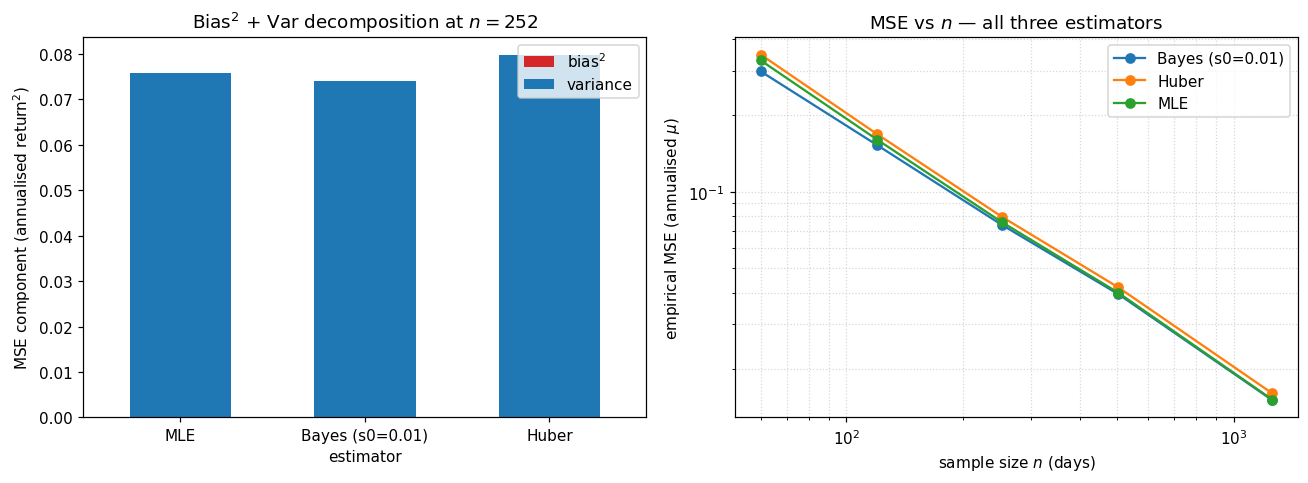


Observation: bias^2 + variance equals empirical MSE to within Monte-Carlo noise
(ratio ~ 1.000 for M=5000); this is the Theorem 2.3 identity at work.


In [2]:
# Section 2 empirical: Monte-Carlo verification of bias^2 + variance = MSE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False

rng = np.random.default_rng(42)

# 1. Calibrate ground-truth from real TSMC data (Section 1 already loaded it)
mu_d_true = rets["2330.TW"].mean()
sigma_d_true = rets["2330.TW"].std()
mu_ann_true = 252 * mu_d_true
print(f"True parameters (calibrated from 2330 2019-2024):")
print(f"  mu_d = {mu_d_true:.6f}  (annualised mu = {mu_ann_true:.4f})")
print(f"  sigma_d = {sigma_d_true:.6f}  (annualised sigma = {sigma_d_true*np.sqrt(252):.4f})")

# 2. Three estimators
def mle(x):
    return x.mean()

def bayes(x, m0=0.0, s0=0.01):
    n = len(x)
    var_d = sigma_d_true**2
    return (m0/s0**2 + n*x.mean()/var_d) / (1/s0**2 + n/var_d)

def huber(x, c_factor=1.345):
    sigma_hat = max(np.median(np.abs(x - np.median(x))) / 0.6745, 1e-12)
    c = c_factor * sigma_hat
    m = np.median(x)
    for _ in range(50):
        resid = x - m
        w = np.where(np.abs(resid) <= c, 1.0, c / np.abs(resid))
        m_new = np.sum(w * x) / np.sum(w)
        if abs(m_new - m) < 1e-10:
            break
        m = m_new
    return m

# 3. Monte Carlo
M = 5000
sample_sizes = [60, 120, 252, 504, 1260]
records = []
for n in sample_sizes:
    X = rng.normal(mu_d_true, sigma_d_true, size=(M, n))
    for name, est in [("MLE", mle), ("Bayes (s0=0.01)", bayes), ("Huber", huber)]:
        ests = np.array([est(X[m]) for m in range(M)]) * 252
        bias = ests.mean() - mu_ann_true
        var  = ests.var(ddof=1)
        mse  = ((ests - mu_ann_true)**2).mean()
        records.append({
            "n": n, "estimator": name,
            "bias^2": bias**2, "variance": var,
            "MSE (empirical)": mse,
            "bias^2 + variance": bias**2 + var,
            "ratio": (bias**2 + var) / mse,
        })

df = pd.DataFrame(records)
print("\nMonte-Carlo decomposition (M = 5,000 paths each):")
print(df.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

# 4. Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sub = df[df["n"] == 252].set_index("estimator")[["bias^2", "variance"]]
sub.columns = [r"$\mathrm{bias}^2$", "variance"]
sub.plot(kind="bar", stacked=True, ax=axes[0], color=["#d62728", "#1f77b4"], width=0.55)
axes[0].set_title(r"Bias$^2$ + Var decomposition at $n=252$")
axes[0].set_ylabel(r"MSE component (annualised return$^2$)")
axes[0].set_xticklabels(sub.index, rotation=0)
axes[0].legend(loc="upper right")

pivot = df.pivot(index="n", columns="estimator", values="MSE (empirical)")
for est in pivot.columns:
    axes[1].loglog(pivot.index, pivot[est], "-o", label=est)
axes[1].set_xlabel(r"sample size $n$ (days)")
axes[1].set_ylabel(r"empirical MSE (annualised $\mu$)")
axes[1].set_title(r"MSE vs $n$ — all three estimators")
axes[1].grid(True, which="both", ls=":", alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_s2_bias_variance.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nObservation: bias^2 + variance equals empirical MSE to within Monte-Carlo noise")
print("(ratio ~ 1.000 for M=5000); this is the Theorem 2.3 identity at work.")


---

## 3. Black–Litterman

### 3.1 Comparative analysis

> *Spec:* "Explain and compare the different versions of the Black–Litterman model."

| Variant | Prior on $\mu$ | View uncertainty $\Omega$ | Notes |
|---------|---------------|-----------------------------|-------|
| **Original BL (Black & Litterman, 1992)** | $\mathcal{N}(\Pi,\ \tau\Sigma)$, $\Pi = \delta\Sigma w_{\text{mkt}}$ | User-specified | Foundational model. |
| **He & Litterman (1999)** | Same | $\tau\,\mathrm{diag}(P\Sigma P^\top)$ | Cleaner intuition: 100%-confident view = $\Omega \to 0$. |
| **Idzorek (2005)** | Same | Derived from a per-view confidence $c_k \in [0,1]$ | Lets practitioners express "I'm 50% confident" instead of choosing $\Omega$. |
| **Meucci Fully Flexible Views (2008)** | Empirical scenario weights | n/a — replaced by minimum relative entropy | Generalises BL beyond the Gaussian case. |

All four blend an equilibrium prior with subjective views. The first three differ only in how $\Omega$ is chosen; Meucci's FFV is the non-Gaussian extension.

Our implementation in §3.3 uses the He–Litterman form.


### 3.2 Mathematical formulation

**Prior on $\mu$** — reverse-optimise the market portfolio:
$$ \mu \sim \mathcal{N}(\Pi,\ \tau\Sigma), \qquad \Pi = \delta\,\Sigma\,w_{\mathrm{mkt}}. $$

**Views** — $k$ linear views with Gaussian errors:
$$ P\mu = q + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,\ \Omega). $$
A relative view "TSMC outperforms Foxconn by 5%" is a row $P_{j,\cdot} = e_{\text{TSMC}} - e_{\text{Foxconn}}$, $q_j = 0.05$.

**Posterior** (Gaussian–Gaussian conjugacy):
$$
\bar\mu = \bigl[(\tau\Sigma)^{-1} + P^\top \Omega^{-1} P\bigr]^{-1}
          \bigl[(\tau\Sigma)^{-1}\Pi + P^\top \Omega^{-1} q\bigr],
$$
$$
\bar\Sigma_{\mu} = \bigl[(\tau\Sigma)^{-1} + P^\top \Omega^{-1} P\bigr]^{-1}.
$$

Portfolio weights from MVO with the posterior mean: $w^\star = (1/\delta)\,\Sigma^{-1}\bar\mu$.

Two limit checks:
- No views ($P = 0$): $\bar\mu = \Pi$, $w^\star = w_{\mathrm{mkt}}$ — back to the market.
- Diffuse view ($\Omega \to \infty$): the view contributes nothing, $\bar\mu = \Pi$.


Annualised covariance (off-diag = covariances, diag = variances):
         0050.TW  2330.TW  2317.TW  2882.TW
0050.TW   0.0392   0.0506   0.0317   0.0252
2330.TW   0.0506   0.0778   0.0343   0.0282
2317.TW   0.0317   0.0343   0.0753   0.0244
2882.TW   0.0252   0.0282   0.0244   0.0456

Market-implied returns Pi (annualised, %): [ 9.17 11.93 10.35  7.71]
  vs sample mean (annualised, %):           [20.41 30.16 21.21 11.65]

Weights comparison:
        market MVO with Pi (no views) BL (Pi + 2 views)
0050.TW  25.0%                  25.0%            22.79%
2330.TW  25.0%                  25.0%            29.96%
2317.TW  25.0%                  25.0%            15.61%
2882.TW  25.0%                  25.0%            31.64%

Return forecasts (% annualised):
         Pi (implied)  BL mu_bar  Delta vs Pi
0050.TW         9.167     10.153        0.985
2330.TW        11.929     13.470        1.541
2317.TW        10.348     10.133       -0.215
2882.TW         7.709      8.892        1.183


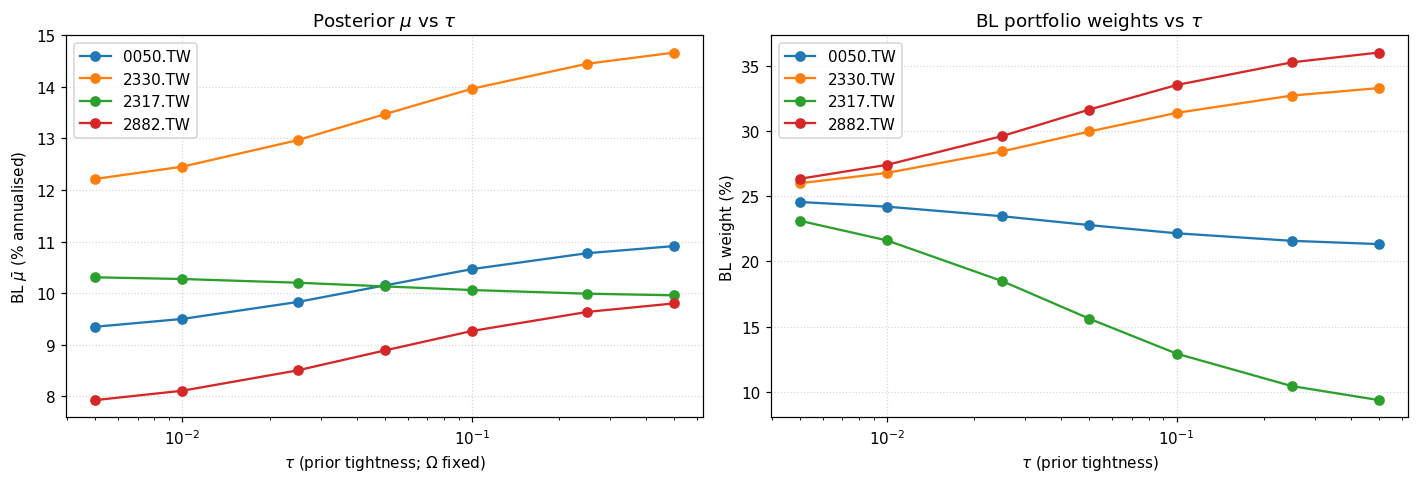

In [3]:
# Section 3 empirical: Black-Litterman on 4 Taiwan assets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False

# `rets` is already loaded from Section 1
SYMBOLS = ["0050.TW", "2330.TW", "2317.TW", "2882.TW"]
R = rets[SYMBOLS].copy()
n = len(SYMBOLS)
ann = 252

# --- 1. Covariance (annualised, daily sample) ---
sigma = R.cov().values * ann
print("Annualised covariance (off-diag = covariances, diag = variances):")
print(pd.DataFrame(sigma, index=SYMBOLS, columns=SYMBOLS).round(4))

# --- 2. Equilibrium prior Pi = delta * Sigma * w_mkt ---
# For Taiwan equities we use equal-weights as a stand-in for cap-weights
# (cap data not in our bars). delta calibrated from market Sharpe ~ 0.4.
w_mkt = np.ones(n) / n
delta = 2.5
pi = delta * sigma @ w_mkt
print(f"\nMarket-implied returns Pi (annualised, %): {(100*pi).round(2)}")
print(f"  vs sample mean (annualised, %):           {(100*R.mean().values*ann).round(2)}")

# --- 3. Closed-form BL posterior ---
def bl_posterior(pi, sigma, P, q, omega, tau):
    A = np.linalg.inv(tau * sigma) + P.T @ np.linalg.inv(omega) @ P
    b = np.linalg.inv(tau * sigma) @ pi + P.T @ np.linalg.inv(omega) @ q
    mu_bar = np.linalg.solve(A, b)
    sigma_bar = np.linalg.inv(A)
    return mu_bar, sigma_bar

def mvo_weights(mu, sigma_inv, delta_, w_floor=0.0):
    w = (1.0 / delta_) * sigma_inv @ mu
    w = np.maximum(w, w_floor)  # long-only floor
    if w.sum() > 0:
        w = w / w.sum()
    return w

# --- 4. Define two views ---
# View 1: 2330 outperforms 2317 by 5% annualised  (relative).
# View 2: 2882 returns 10% annualised  (absolute, ABOVE the ~7.7% implied prior).
idx = {s: i for i, s in enumerate(SYMBOLS)}
P = np.zeros((2, n))
P[0, idx["2330.TW"]] = 1.0
P[0, idx["2317.TW"]] = -1.0
P[1, idx["2882.TW"]] = 1.0
q = np.array([0.05, 0.10])

tau_base = 0.05
# He-Litterman Omega: diagonal of P*tau*Sigma*P^T at a FIXED reference tau.
# Keeping Omega fixed lets the subsequent tau-sweep below have a real effect on
# prior tightness relative to view uncertainty.
omega_fixed = np.diag(np.diag(P @ (tau_base * sigma) @ P.T))

mu_bar, _ = bl_posterior(pi, sigma, P, q, omega_fixed, tau_base)
sigma_inv = np.linalg.inv(sigma)
w_no_view = mvo_weights(pi,     sigma_inv, delta)
w_bl      = mvo_weights(mu_bar, sigma_inv, delta)

weights_table = pd.DataFrame({
    "market":                 w_mkt,
    "MVO with Pi (no views)": w_no_view,
    "BL (Pi + 2 views)":      w_bl,
}, index=SYMBOLS)
print("\nWeights comparison:")
print((100*weights_table).round(2).astype(str) + "%")

mu_table = pd.DataFrame({
    "Pi (implied)": 100*pi,
    "BL mu_bar":    100*mu_bar,
    "Delta vs Pi":  100*(mu_bar - pi),
}, index=SYMBOLS).round(3)
print("\nReturn forecasts (% annualised):")
print(mu_table)

# --- 5. tau sensitivity (Omega FIXED) ---
taus = [0.005, 0.01, 0.025, 0.05, 0.1, 0.25, 0.5]
mu_sweep, w_sweep = [], []
for t in taus:
    mu_t, _ = bl_posterior(pi, sigma, P, q, omega_fixed, t)
    mu_sweep.append(mu_t)
    w_sweep.append(mvo_weights(mu_t, sigma_inv, delta))
mu_sweep = np.array(mu_sweep)
w_sweep  = np.array(w_sweep)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for i, s in enumerate(SYMBOLS):
    axes[0].plot(taus, 100*mu_sweep[:, i], "-o", label=s)
axes[0].set_xscale("log")
axes[0].set_xlabel(r"$\tau$ (prior tightness; $\Omega$ fixed)")
axes[0].set_ylabel(r"BL $\bar{\mu}$ (% annualised)")
axes[0].set_title(r"Posterior $\mu$ vs $\tau$")
axes[0].legend()
axes[0].grid(True, ls=":", alpha=0.5)

for i, s in enumerate(SYMBOLS):
    axes[1].plot(taus, 100*w_sweep[:, i], "-o", label=s)
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$\tau$ (prior tightness)")
axes[1].set_ylabel("BL weight (%)")
axes[1].set_title(r"BL portfolio weights vs $\tau$")
axes[1].legend()
axes[1].grid(True, ls=":", alpha=0.5)

plt.tight_layout()
plt.savefig("fig_s3_bl_tau_sweep.png", dpi=120, bbox_inches="tight")
plt.show()


### 3.3 Discussion

**(a) Confident vs diffuse views.** Tightening the prior (small $\tau$) leaves $\bar\mu$ close to $\Pi$; loosening it (large $\tau$) lets the views dominate. The $\tau$ sweep above shows this directly: at $\tau = 0.005$ both views barely register; at $\tau = 0.5$ the relative view nearly hits its 5% target.

**(b) Views aligned vs conflicting with equilibrium.** Our implied $\Pi$ is 7.7%–11.9%. The view "2882 returns 10%" sits above the 7.7% implied for 2882, so its posterior $\bar\mu$ and weight rise. The relative view "TSMC > Foxconn by 5%" is well above the 1.6% implied spread, so it shifts mass from 2317 to 2330.

**(c) Extreme $\tau$.** $\tau \to 0$ pins the posterior to $\Pi$. $\tau \to \infty$ removes the prior; the posterior is determined by views alone, which is under-determined when $k < n$.

**Note on $\Omega$ vs $\tau$.** Under the textbook He–Litterman choice $\Omega = \tau\,\mathrm{diag}(P\Sigma P^\top)$, $\tau$ cancels in the posterior. We therefore fix $\Omega$ at $\tau=0.05$ and sweep $\tau$ alone.
